In [87]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
# load in data
bills = pd.read_csv("bill_details.csv")
rename = {'Legislation Number':'bill_id',  'Title':'bill_name',
       'Latest Tracker Stage':'all_status', 'Latest Summary':'summary'}
bills = bills.rename(columns=rename).drop('Congress', axis=1)
bills['binary_status'] = (bills['all_status'] == "Became Law").astype(int)

In [89]:
bills.head()

,bill_id,URL,bill_name,all_status,summary,binary_status
0,H.R. 5371,https://www.congress.gov/bill/119th-congress/h...,"Continuing Appropriations, Agriculture, Legisl...",Became Law,"<p><strong>Continuing Appropriations, Agricult...",1
1,H.R. 5143,https://www.congress.gov/bill/119th-congress/h...,District of Columbia Policing Protection Act o...,Passed House,<p><strong>District of Columbia Policing Prote...,0
2,H.R. 5140,https://www.congress.gov/bill/119th-congress/h...,To lower the age at which a minor may be tried...,Passed House,<p>This bill lowers the age at which an indivi...,0
3,H.R. 5125,https://www.congress.gov/bill/119th-congress/h...,District of Columbia Judicial Nominations Refo...,Passed House,<p><strong>District of Columbia Judicial Nomin...,0
4,H.R. 5100,https://www.congress.gov/bill/119th-congress/h...,"To extend the SBIR and STTR programs, and for ...",Passed House,<p>This bill reauthorizes through FY2026 the S...,0


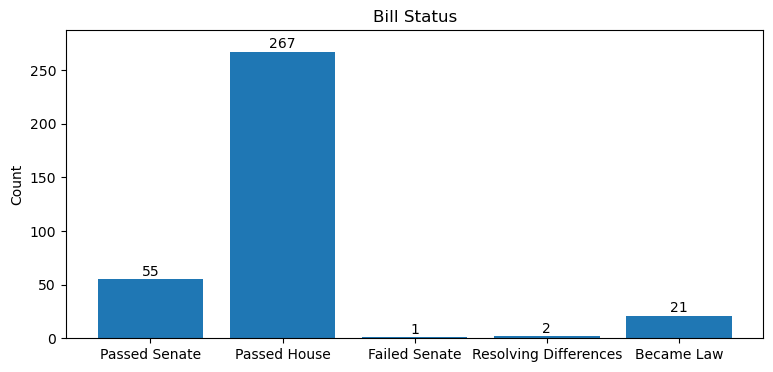

In [90]:
# bar plot with all bill statuses
plt.figure(figsize=(9,4))
status_counts = bills['all_status'].value_counts()
order = ["Passed Senate", "Passed House", "Failed Senate", "Resolving Differences", "Became Law"]
status_counts = status_counts.reindex(order)
plt.bar(status_counts.index, status_counts.values)

plt.ylabel('Count')
plt.title('Bill Status')
plt.ylim(0, max(status_counts.values)+20)

# add actual counts above bars
for x, count in zip(status_counts.index, status_counts.values):
    plt.text(x, count + 0.5, str(count), ha='center', va='bottom')

plt.savefig("visualizations/current_bill_status.png")
plt.show()

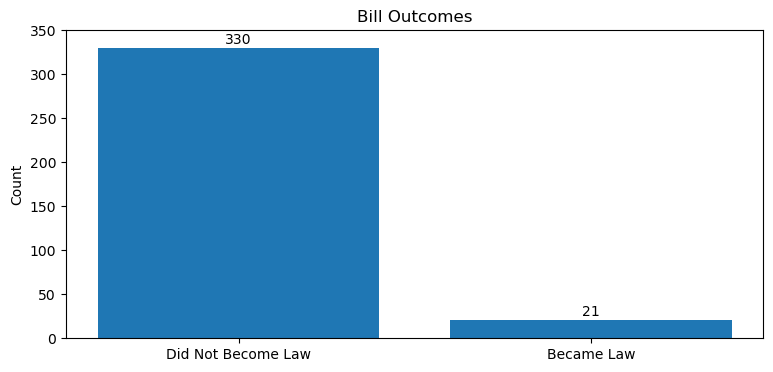

In [91]:
# bar plot with binary bill statuses
status_counts = bills['binary_status'].value_counts().sort_index()
labels = {0: "Did Not Become Law", 1: "Became Law"}
x_labels = [labels[i] for i in status_counts.index]

plt.figure(figsize=(9,4))
plt.bar(x_labels, status_counts.values)
plt.ylim(0, max(status_counts.values)+20)

# add actual counts above bars
for x, count in zip(x_labels, status_counts.values):
    plt.text(x, count + 0.5, str(count), ha='center', va='bottom')

plt.ylabel('Count')
plt.title('Bill Outcomes')
plt.savefig("visualizations/bill_outcomes.png")
plt.show()